In [1]:
%matplotlib widget
import json
from itertools import product
from functools import partial, reduce
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
import tempfile
import multiprocessing as mp

import hopsy
import plotly.express as px
from diskcache import Cache
from freeflux import Model
from pathlib import Path

from tqdm import tqdm
from scipy.spatial.distance import pdist, cdist, cosine

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

from mfa import (
    reac2array,
    create_add_constraints,
    get_model,
    make_bounds, 
    sample_fluxes, 
    get_mdv_results, 
    get_mdv_results_from_simulations,
    get_single_sim_result,
    get_reconex_fluxes,
    get_flux_ratio,
    get_flux_ratio_onlypos,
    get_flux_ratio,
    get_all_flux_ratios,
    subset_fluxes_by_binned_flux_ratio,
    subset_mdvs_by_binned_flux_ratio,
    train_rf
)
from flux_mdv_utils import (
    xy_line, 
    melt_flux_df, 
    melt_mdv_df,
    get_sumoflux_fluxes,
    get_flux_ratio,
    get_highest_flux_diff,
    get_highest_mdv_diff,
    convert_sumoflux_notation,
    plot_fluxes,
    plot_mdvs_boxplots,
    plot_rf_results
)

sns.set_theme()

cache = Cache("../.cache")

output_dir = Path("../Output/CofeedBuni/")
output_dir.mkdir(parents=True, exist_ok=True)

parallel = 100


def read_config(path_to_file):
    with open(path_to_file) as fh:
        return json.load(fh)

def get_feat_importance(rf_results, feature_names):
    return pd.concat([
        (
            pd.DataFrame({
                "feature": feature_names, 
                "importance": ratio_res[0].feature_importances_
            })
            .assign(ratio_name=ratio_name)
            .sort_values("importance", ascending=False)
        ) for ratio_name, ratio_res in rf_results.items()
    ])

def predict_interval(model, X, lower=5, upper=95):
    # Collect predictions from all individual trees
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])
    # tree_preds shape: (n_estimators, n_samples)
    
    lower_bound = np.percentile(tree_preds, lower, axis=0)
    upper_bound = np.percentile(tree_preds, upper, axis=0)
    point_pred  = np.mean(tree_preds, axis=0)
    
    return point_pred, lower_bound, upper_bound

def get_rf_pred_results(rf_dict, df_exp, condition, q_lower=10, q_upper=90, replace_w_nans=True):
    pred_df = (
        pd.DataFrame([
            [
                condition, 
                ratio_name, 
                *predict_interval(ratio_res[0], df_exp.mdv.to_frame().transpose().values, q_lower, q_upper), 
                *ratio_res[1].values()
            ] 
            for ratio_name, ratio_res in rf_dict.items()
        ], columns=(
            "condition", 
            "flux_ratio", 
            "pred", 
            "pred_q10", 
            "pred_q90",
            "mae", 
            "cv_mae_mean", 
            "cv_mae_sd"
        ))
        .explode(["pred", "pred_q10", "pred_q90"])
        .pipe(lambda x: x.join(x.flux_ratio.str.extract(r"(?P<nucleoside>.*)_(?P<flux_ratio_name>.*)")))
    )
    
    if replace_w_nans and df_exp.mdv.isna().any():
        pred_df = pred_df.assign(pred=np.nan, pred_q10=np.nan, pred_q90=np.nan)
    return pred_df

def lineplots(data, x="pred", y="condition", **kwargs):
    sns.stripplot(
        data,
        x=x,
        y=y,
        hue=y,
    )
    
    sns.lineplot(
        data
        .melt(
            id_vars=list({"condition", "flux_ratio", y}), 
            value_vars=["pred_q10", "pred_q90"]
        ),
        x="value",
        y=y,
        hue=y
    )

def add_exp_points(facet_grid, exp_df, color="red", **kwargs):
    for emu, data in exp_df.groupby("emu"):
        if emu in facet_grid.axes_dict:
            ax = facet_grid.axes_dict[emu]
            sns.scatterplot(
                data, 
                x="m", 
                y="mdv", 
                color=color,
                ax=ax, 
                zorder=1000,
                **kwargs
            )
            ax.errorbar(
                x=data.m,
                y=data.mdv,
                yerr=data.sd,
                fmt="none",
                color=color,
                capsize=5,
            )
    return facet_grid

def get_features_list(mdvs_df, exp_df, medium):
    return (
        mdvs_df
        .index
        .intersection(exp_df.query("medium == @medium").isotopo)
        # .intersection(exp_df.query("medium == @medium2").isotopo)
        .tolist()
    )

def get_features_from_exp(data, medium, features):
    return (
        data
        .query("medium == @medium")
        .copy()
        .query("isotopo in @features")
        .set_index("isotopo")
        .reindex(features)
        # .mdv
        # .to_frame()
        # .transpose()
    )

def train_rf_for_all_flux_ratios(fluxes_df, mdvs_df, flux_ratios):
    input_args = [
        (fluxes_df, mdvs_df, name, *ratio, 0.3) for name, ratio in flux_ratios.items()
    ]
    with mp.Pool(3) as p:
        res = p.starmap(train_rf, input_args)
    
    res_dict = {name: ind_res for (_, _, name, _, _, _), ind_res in zip(input_args, res)}
    df_feat_imp = get_feat_importance(res_dict, mdvs_df.index.tolist())
    
    return res_dict, df_feat_imp

def check_mdv_nan(data):
    return (
        data
        .query("mdv.isna()")
        .index.str.extract("(.*)_.*_.*")
        .drop_duplicates()
        .iloc[:, 0]
        .tolist()
    )

df_exp = (
    pd.read_csv("../Data/CofeedExp/labeling_patterns_Buni.csv")
    .pipe(lambda x: x.join(
        x.isot_model_name.str.extract(r"(?P<mb>.*)_(?P<atomnos>.*)_(?P<m>.*)", expand=True)
    ))
    .drop(columns="atomnos")
    .assign(m=lambda x: x.m.astype(int))
    .pipe(lambda x: x.merge(
        x.groupby('mb')["m"].max().apply(lambda x: "".join([str(y) for y in range(1, x+1)])).rename("atomnos").reset_index(),
        on="mb",
        how="left"
    ))
    .assign(
        isotopo=lambda x: x.mb + "_" + x.atomnos + "_" + x.m.astype(str),
        emu=lambda x:  x.mb + "_" + x.atomnos
    )
    .rename(columns={"mean": "mdv"})
)

# Simulations

In [2]:
target_emus_dict = {
    "G6P": [1,2,3,4,5,6],
    "F6P": [1,2,3,4,5,6],
    "Pyr": [1,2,3],
    "S7P": [1,2,3,4,5,6,7],
    "Cit": [1,2,3,4,5,6],
    "Suc": [1,2,3,4],
    "Fum": [1,2,3,4],
    "Val": [1,2,3,4,5],
    "Gln": [1,2,3,4,5],
    "Arg": [1,2,3,4,5,6],
    "Thr": [1,2,3,4],
    "Met": [1,2,3,4,5],
    "Asp": [1,2,3,4],
    "Asn": [1,2,3,4],
    "Ser": [1,2,3],
    "Phe": [1,2,3,4,5,6,7,8,9],
    "Tyr": [1,2,3,4,5,6,7,8,9]
}

add_target_emus = {
    "Trp": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "AMP": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "ADN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "ADE": [1, 2, 3, 4, 5],
    "dADN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

bounds_dict = {
    "lb_val": 0, 
    "ub_val": 100, 
    "specific": {
        "glk": [10, 10], 
        "co2in": [90, 100],
        "co2out": [0, 100]
    }
}

labelling_dict = dict(
    labeled_substrate = "Glc.ex", 
    labeling_pattern = ['111111'], 
    percentage = [1], 
    purity = [0.994]
)

flux_ratios_dict = {
    "glycolysis_PPP": (["pgi"], ["pgi", "g6pdh"]),
    "PEP_from_OAA": (["pyc"], ["pyc", "eno"]), 
    "Pyr_from_PEP": (["pk"], ["pk", "me", "oad", "pdh"]), 
    "OAA_from_PEP": (["pyc"], ["pyc", "mdh", "pc"]), 
    "AKG_from_Suc": (["kdh"], ["kdh", "icd"]), 
    "Mal_from_Fum": (["fum"], ["fum", "mdh", "me"]), 
    "OAA_from_Mal": (["mdh"], ["mdh", "pyc", "pc"]), 
    "Pyr_from_OAA": (["oad"], ["oad", "pk", "me", "pdh"]), # species specific
    "Mal_from_Pyr": (["me"], ["me", "mdh", "fum"])
}

add_flux_ratios_dict = {
    'ADN_uptake': [['ADNin'], ['RAICAR', 'ADNin']],
    'ADN_phos': [['ADNK1'], ['ADNK1', 'RAICAR']],
    "ADN_ccm": [["ADNUC", "PUNP1"], ["ADNUC", "PUNP1", "ADNK1", "adnbm"]]
}

model_file = "../Config/Models/Buniformis/Buniformis_individualBiomass_nucleosides_with_RIBbm_ADN.tsv"

In [3]:
new_frs = flux_ratios_dict | add_flux_ratios_dict

bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["NTD7"] = [0, 10]
bounds_dict2["specific"]["ADNin"] = [0, 1]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

lb, ub = make_bounds(stoich_mat, **bounds_dict2)
fr_bounds = {
    k: [v, (0, 1)]
    for k, v in new_frs.items()
}
add_constraints = create_add_constraints(stoich_mat, fr_bounds)

df_fluxes1 = sample_fluxes(stoich_mat, 5000, lb, ub, thinning=1000, add_constraints=add_constraints, reconex=20)
df_mdvs1 = get_mdv_results_from_simulations(
    model,
    df_fluxes1,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

In [4]:
bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["NTD7"] = [0, 10]
bounds_dict2["specific"]["ADNin"] = [0, 1]
bounds_dict2["specific"]["RAICAR"] = [0, 1]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

bins = np.arange(0, 1.1, 0.1)
intervals = np.array([bins[:-1], bins[1:]]).T

df_all_fluxes = []

for int1, int2 in tqdm(product(intervals, intervals)):
# for int1 in tqdm(intervals):
    fr_bounds = {
        "ADN_uptake": [add_flux_ratios_dict["ADN_uptake"], int1],
        'ADN_phos': [add_flux_ratios_dict["ADN_phos"], int2]
    }
    add_constraints = create_add_constraints(stoich_mat, fr_bounds)

    lb, ub = make_bounds(stoich_mat, **bounds_dict2)
    try:
        df_fluxes = sample_fluxes(stoich_mat, 50, lb, ub, thinning=1000, add_constraints=add_constraints, add_constraints_b=[0, 0, 0, 0])
    except ValueError as e:
        print(e)
    else:
        df_all_fluxes.append(df_fluxes)

df_fluxes2 = pd.concat(df_all_fluxes, axis=1, ignore_index=True)

df_mdvs2 = get_mdv_results_from_simulations(
    model,
    df_fluxes2,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

100it [01:15,  1.33it/s]


In [5]:
bounds_dict2 = deepcopy(bounds_dict)
bounds_dict2["specific"]["ADNin"] = [0, 1]
bounds_dict2["specific"]["NTD7"] = [0, 0]

model = get_model(model_file)
stoich_mat = model.get_total_stoichiometric_matrix()

lb, ub = make_bounds(stoich_mat, **bounds_dict2)
fr_bounds = {
    k: [v, (0, 1)]
    for k, v in flux_ratios_dict.items()
}
add_constraints = create_add_constraints(stoich_mat, fr_bounds)

df_fluxes3 = sample_fluxes(stoich_mat, 1000, lb, ub, thinning=1000, add_constraints=add_constraints, reconex=20)

df_mdvs3 = get_mdv_results_from_simulations(
    model,
    df_fluxes3,
    target_emus_dict | add_target_emus,
    labelling_dict,
    parallel=parallel
)

In [6]:
df_fluxes = pd.concat([df_fluxes1, df_fluxes2, df_fluxes3], axis=1, ignore_index=True)
df_mdvs = pd.concat([df_mdvs1, df_mdvs2, df_mdvs3], axis=1, ignore_index=True)

In [7]:
df_fluxes.reset_index(names="reaction_id").to_csv("../Output/CofeedBuni/adn_fluxes.csv", index=False)

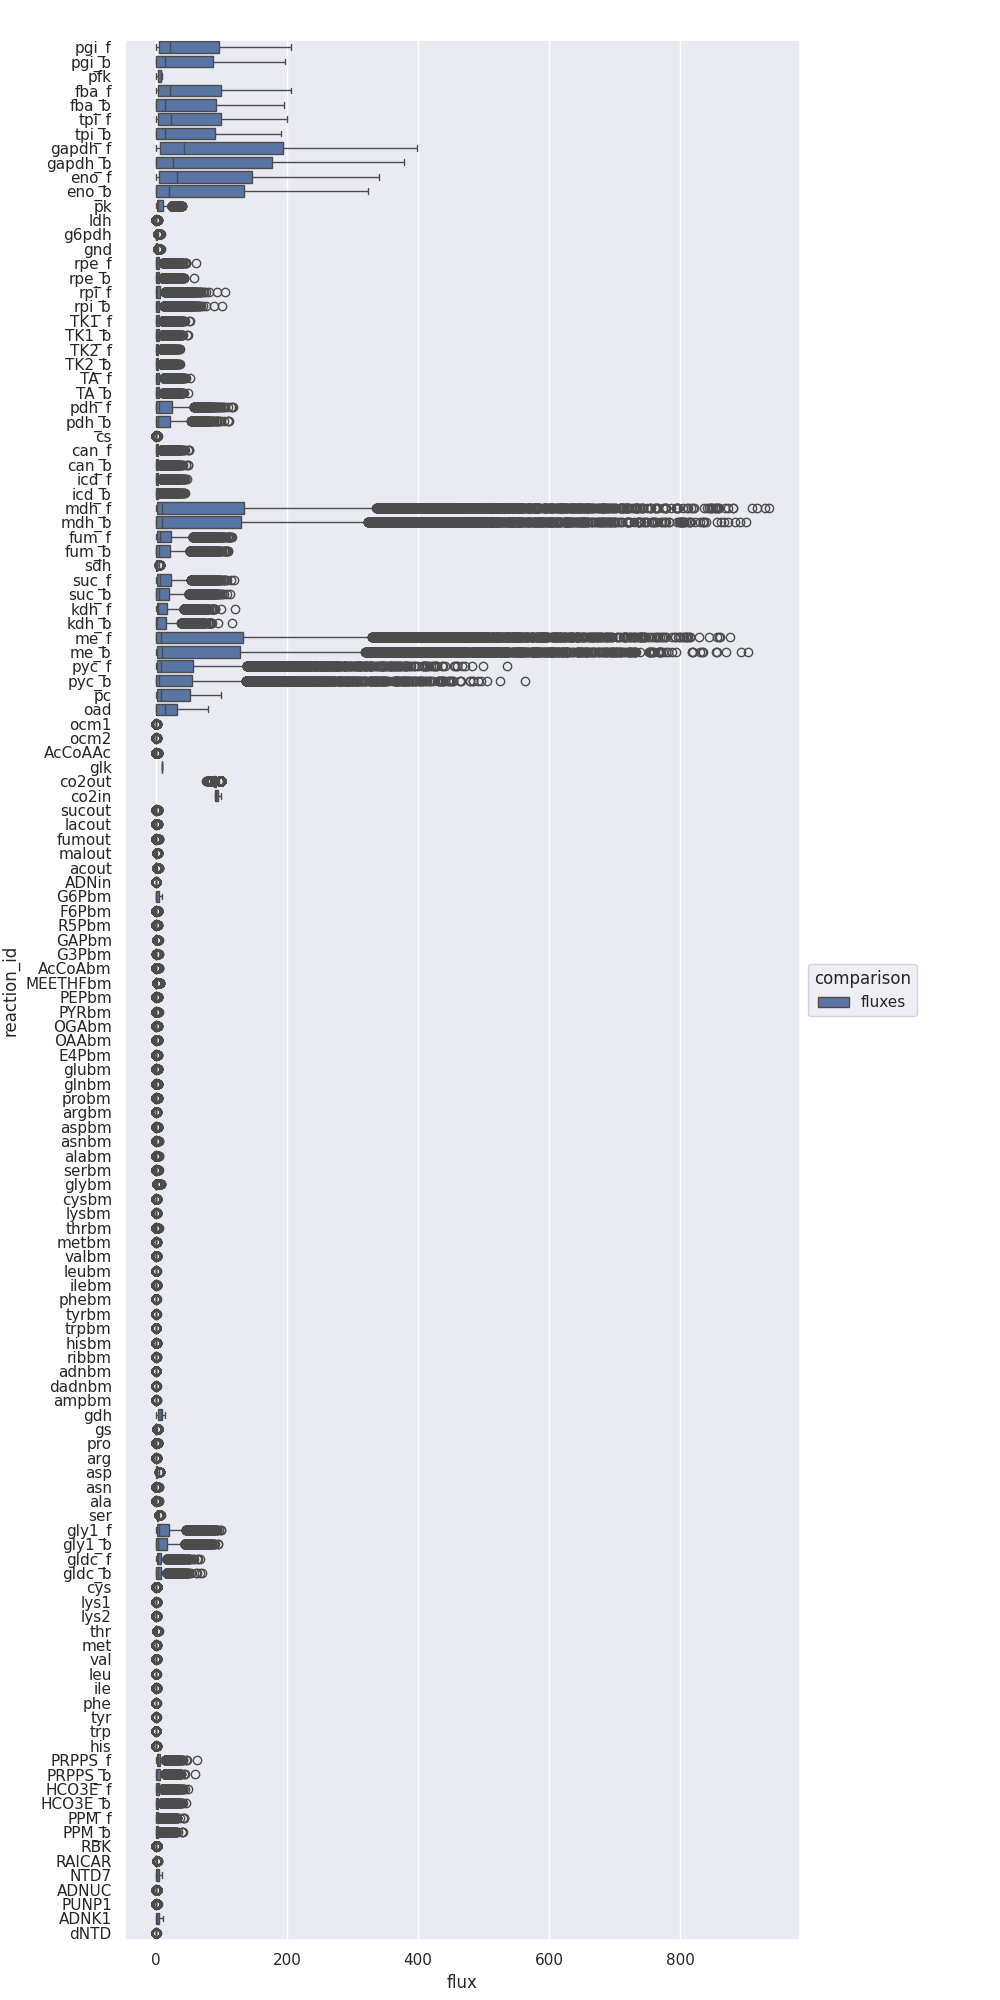

In [8]:
fig = plot_fluxes(
    sns.boxplot,
    fluxes=df_fluxes,
    figsize=(10, 20)
)
fig.subplots_adjust(top=0.98, bottom=0.03)

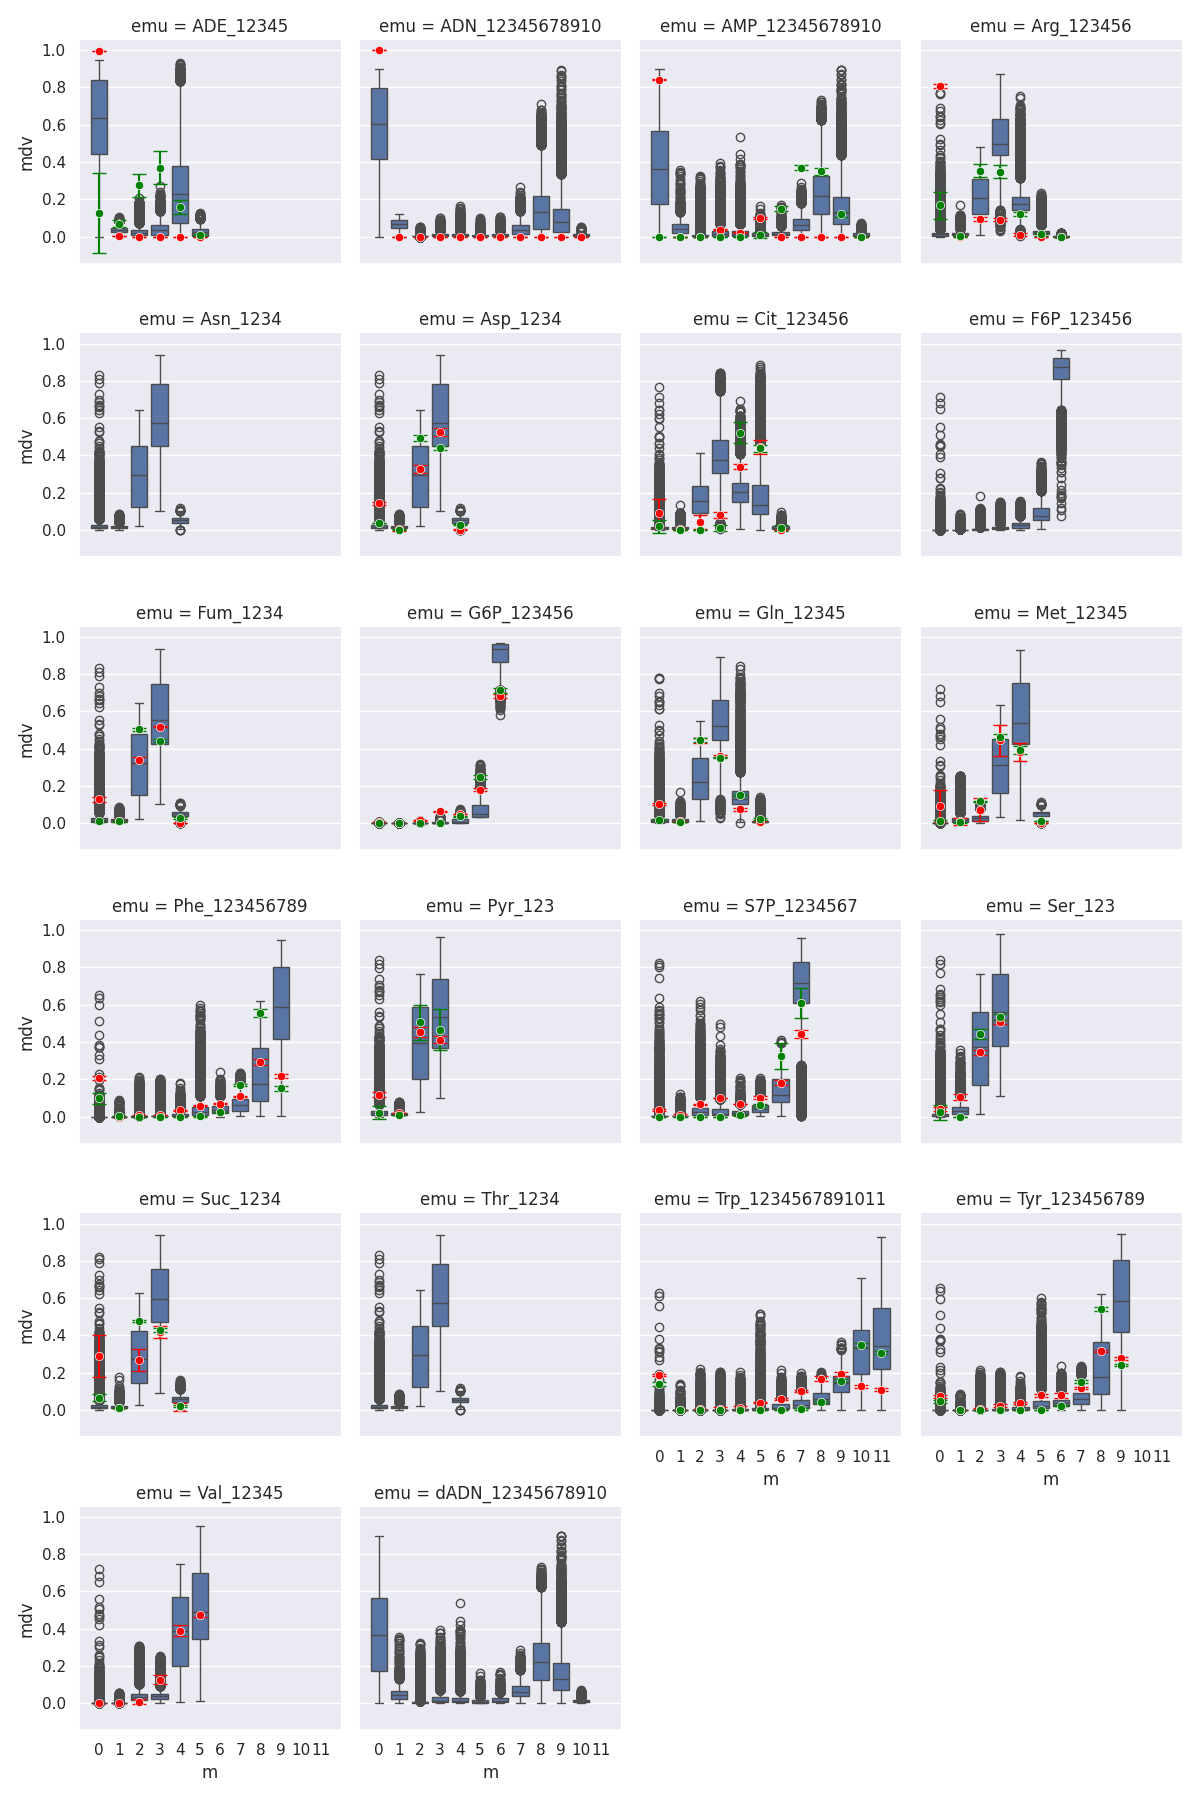

In [9]:
fg = (
    df_mdvs
    .pipe(plot_mdvs_boxplots)
    .pipe(add_exp_points, df_exp.query("medium == 'Adenosine'"))
    .pipe(add_exp_points, df_exp.query("medium == 'Glucose'"), color="green")
)

In [10]:
def add_noise(data, noise_scale=0.01, seed=42):
    rng = np.random.default_rng(seed)
    new_data = (data + rng.uniform(-noise_scale, noise_scale, size=data.shape)).abs()
    return new_data / new_data.sum(axis=0)

In [11]:
df_mdvs_with_noise = (
    df_mdvs
    .reset_index(names="isotopo")
    .pipe(lambda x: x.join(x.isotopo.str.extract("(?P<mb>.*)_.*_.*")))
    .set_index("isotopo")
    .groupby("mb")
    .transform(add_noise)
)

In [12]:
df_exp_w_noise = pd.concat([
    g.assign(mdv=add_noise(g.mdv))
    for idx, g in
    df_exp
    .groupby(["strain", "medium", "emu"], as_index=False)
], ignore_index=True)

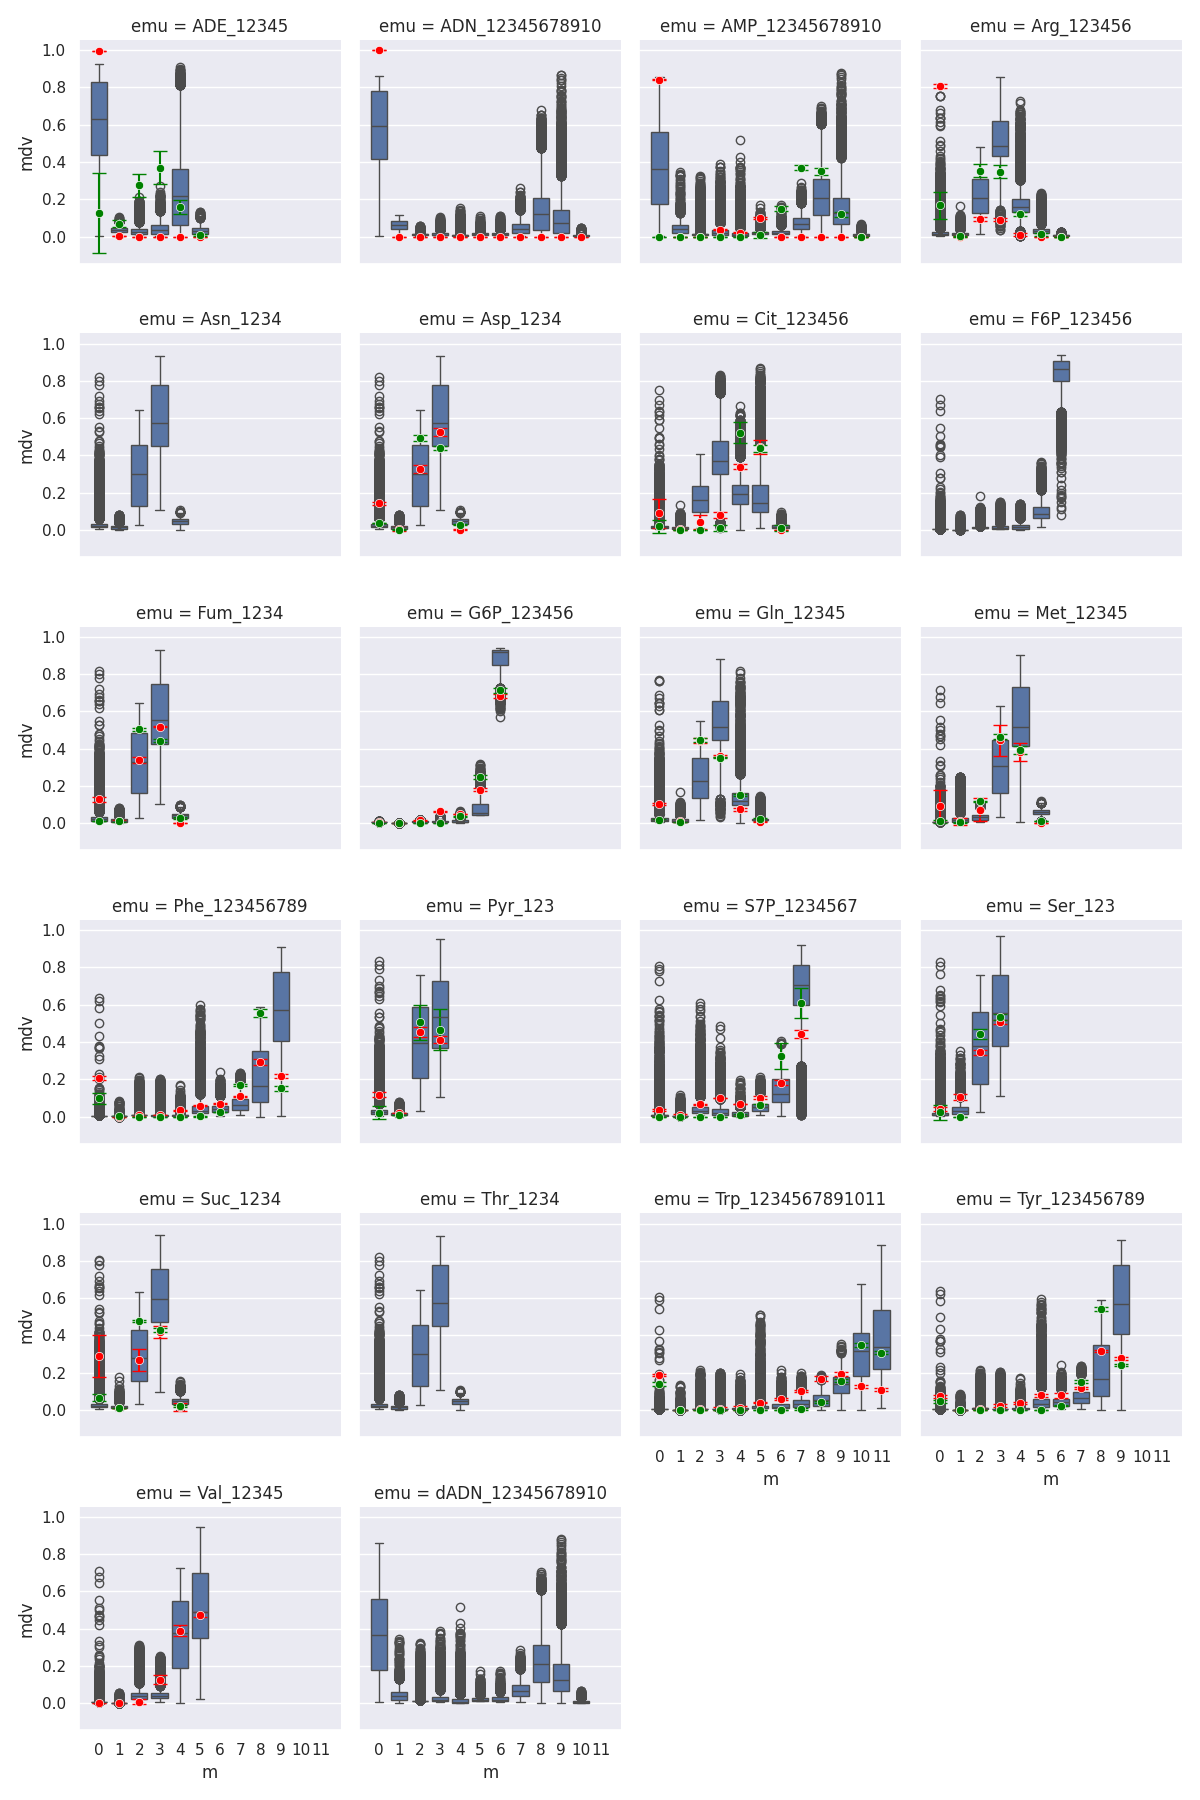

In [13]:
fg = (
    df_mdvs_with_noise
    .pipe(plot_mdvs_boxplots)
    .pipe(add_exp_points, df_exp.query("medium == 'Adenosine'"))
    .pipe(add_exp_points, df_exp.query("medium == 'Glucose'"), color="green")
)

## Additional plots

In [14]:
df_tmp = pd.DataFrame(dict(
    ADN_12345678910_0=
        # pd.concat([df_mdvs1, df_mdvs2], axis=1, ignore_index=True)
        df_mdvs
        .loc["ADN_12345678910_0"].reset_index(drop=True), 
    ADN_uptake=
        # pd.concat([df_fluxes1, df_fluxes2], axis=1, ignore_index=True)
        df_fluxes
        .pipe(lambda x: x.loc["ADNin"] / (x.loc["NTD7"] + x.loc["ADNin"]))
        .reset_index(drop=True),
    ADNin=
        # pd.concat([df_fluxes1, df_fluxes2], axis=1, ignore_index=True)
        df_fluxes
        .loc["ADNin"]
))
df_tmp

,ADN_12345678910_0,ADN_uptake,ADNin
0,0.620520,0.448474,0.970504
1,0.483518,0.328198,0.842778
2,0.562246,0.325109,0.980306
3,0.524651,0.238505,0.851819
4,0.391027,0.201027,0.550059
...,...,...,...
10995,0.898008,1.000000,0.983137
10996,0.898008,1.000000,0.944531
10997,0.898008,1.000000,0.964162
10998,0.898008,1.000000,0.848407


<Axes: xlabel='ADNin', ylabel='NTD7'>

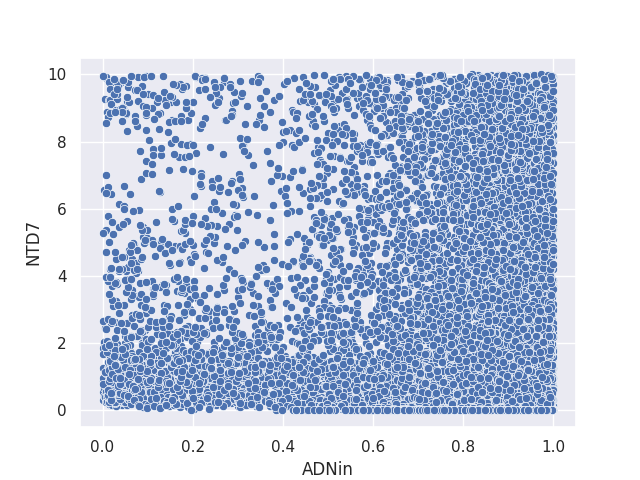

In [15]:
fig, ax = plt.subplots()
sns.scatterplot(df_fluxes.transpose(), x="ADNin", y="NTD7")

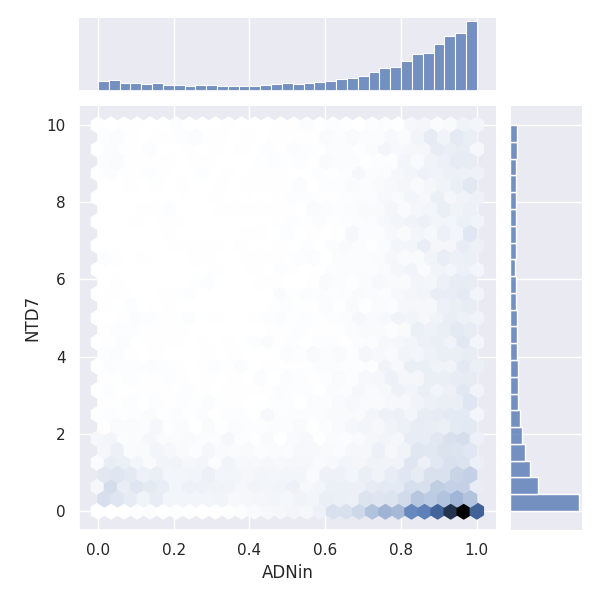

In [16]:
# fig, ax = plt.subplots()
sns.jointplot(df_fluxes.transpose(), x="ADNin", y="NTD7", kind="hex")

<Axes: xlabel='ADN_uptake', ylabel='ADN_12345678910_0'>

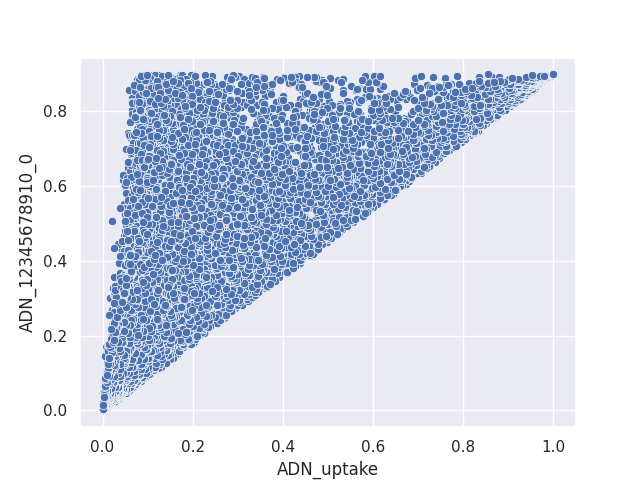

In [17]:
fig, ax = plt.subplots()
sns.scatterplot(df_tmp, x="ADN_uptake", y="ADN_12345678910_0")

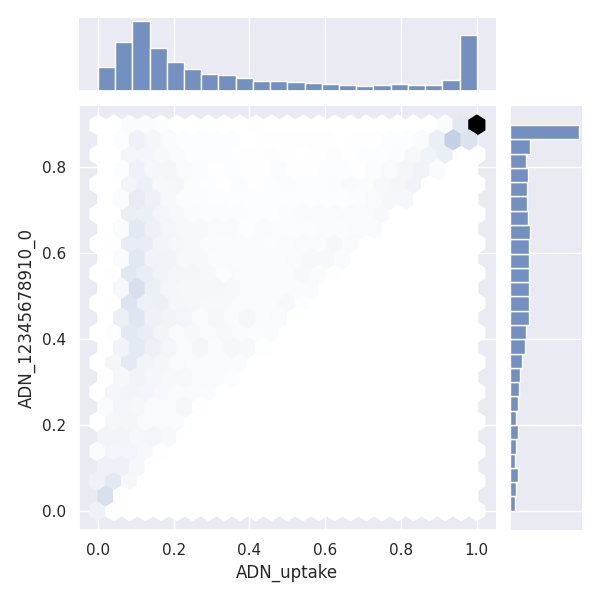

In [18]:
sns.jointplot(df_tmp, x="ADN_uptake", y="ADN_12345678910_0", kind="hex")

# RF models

## Full

Full RF model on all features in the given nucleoside condition

In [19]:
isotopo_list_full = get_features_list(df_mdvs_with_noise, df_exp, "Adenosine")
df_exp_full = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_full)
df_exp_full_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_full)
df_mdvs_full = df_mdvs_with_noise.reindex(isotopo_list_full)

In [20]:
res_full, df_feat_imp_full = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_full, add_flux_ratios_dict)

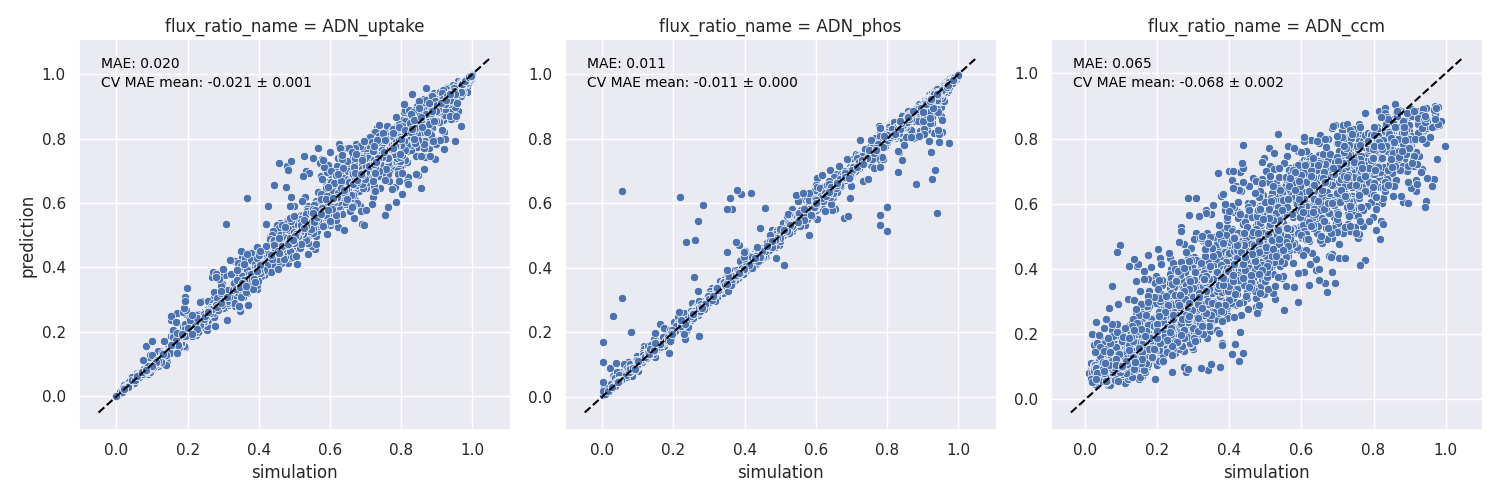

In [21]:
fg = plot_rf_results(res_full, col_wrap=3)

In [22]:
df_pred_full = (
    pd.concat([
        get_rf_pred_results(res_full, df_exp_full, "Adenosine"),
        get_rf_pred_results(res_full, df_exp_full_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="full")
)

df_pred_full

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.683189,0.115203,0.919737,0.020315,-0.021249,0.000943,ADN,uptake,full
1,Adenosine,ADN_phos,0.939261,0.895835,0.996268,0.010626,-0.011486,0.000280,ADN,phos,full
2,Adenosine,ADN_ccm,0.617268,0.373196,0.82731,0.064999,-0.068399,0.001931,ADN,ccm,full
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020315,-0.021249,0.000943,ADN,uptake,full
4,Glucose,ADN_phos,NaN,NaN,NaN,0.010626,-0.011486,0.000280,ADN,phos,full
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.064999,-0.068399,0.001931,ADN,ccm,full


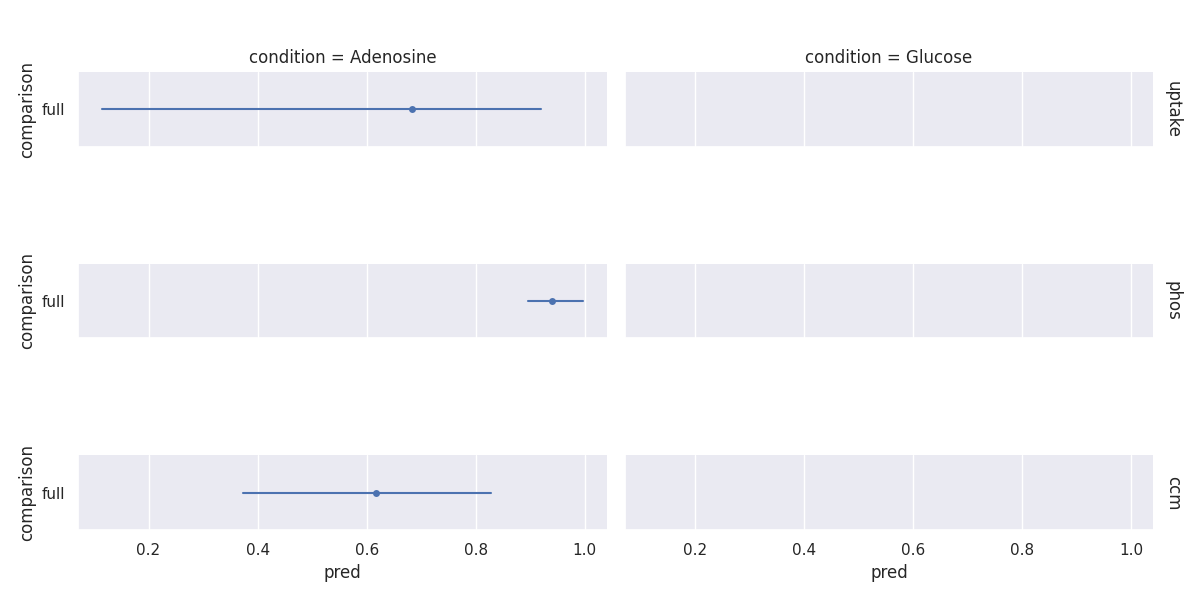

In [23]:
fg = (
    sns.FacetGrid(
        df_pred_full,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [24]:
df_feat_imp_full

,feature,importance,ratio_name
6,ADN_12345678910_0,0.358047,ADN_uptake
0,ADE_12345_0,0.307642,ADN_uptake
7,ADN_12345678910_1,0.204251,ADN_uptake
18,AMP_12345678910_1,0.058158,ADN_uptake
1,ADE_12345_1,0.023905,ADN_uptake
...,...,...,...
102,Trp_1234567891011_0,0.000531,ADN_ccm
71,Phe_123456789_0,0.000524,ADN_ccm
78,Phe_123456789_7,0.000490,ADN_ccm
119,Tyr_123456789_5,0.000489,ADN_ccm


## Without nucleoside

RF model on all features in the given nucleoside condition without nucleoside itself

In [25]:
isotopo_list_wo_nuc = get_features_list(df_mdvs_with_noise, df_exp.query("~isotopo.str.startswith('ADN')"), "Adenosine")
df_exp_wo_nuc = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_wo_nuc)
df_exp_wo_nuc_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_wo_nuc)
df_mdvs_wo_nuc = df_mdvs_with_noise.reindex(isotopo_list_wo_nuc)

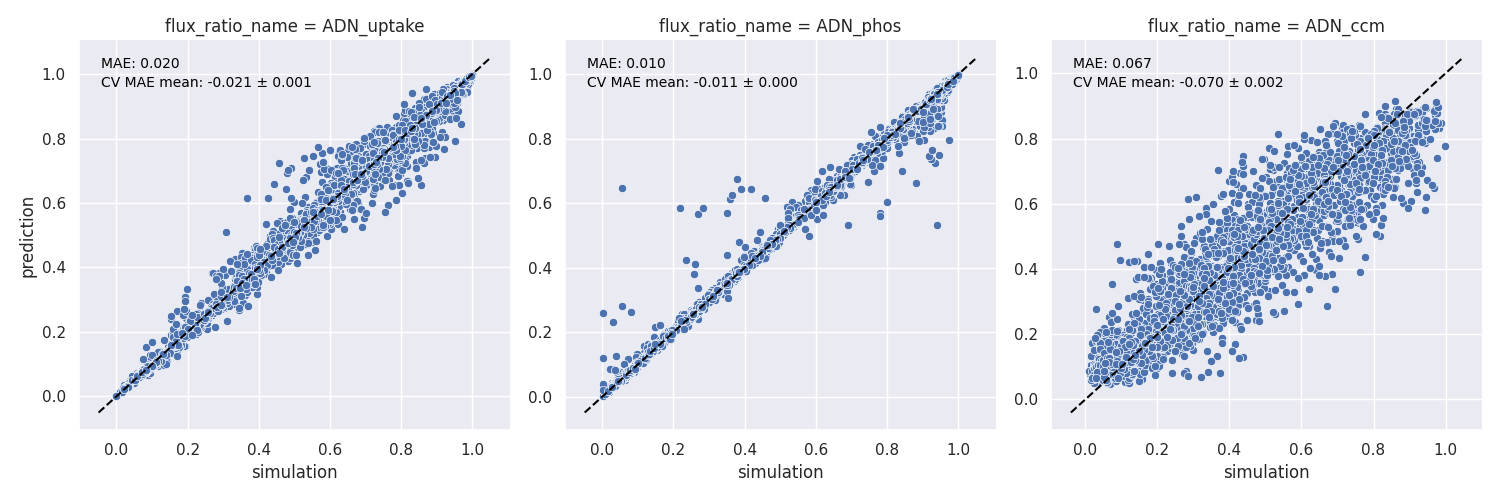

In [26]:
res_wo_nuc, df_feat_imp_wo_nuc = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_wo_nuc, add_flux_ratios_dict)
fg = plot_rf_results(res_wo_nuc, col_wrap=3)

In [27]:
df_pred_wo_nuc = (
    pd.concat([
        get_rf_pred_results(res_wo_nuc, df_exp_wo_nuc, "Adenosine"),
        get_rf_pred_results(res_wo_nuc, df_exp_wo_nuc_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="wo nuc")
)

df_pred_full

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.683189,0.115203,0.919737,0.020315,-0.021249,0.000943,ADN,uptake,full
1,Adenosine,ADN_phos,0.939261,0.895835,0.996268,0.010626,-0.011486,0.000280,ADN,phos,full
2,Adenosine,ADN_ccm,0.617268,0.373196,0.82731,0.064999,-0.068399,0.001931,ADN,ccm,full
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020315,-0.021249,0.000943,ADN,uptake,full
4,Glucose,ADN_phos,NaN,NaN,NaN,0.010626,-0.011486,0.000280,ADN,phos,full
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.064999,-0.068399,0.001931,ADN,ccm,full


In [28]:
df_exp_wo_nuc.pipe(check_mdv_nan), df_exp_wo_nuc_glucose.pipe(check_mdv_nan)

([], ['Val'])

## Glucose features 

RF model on all features in GLC condition

In [29]:
isotopo_list_glc = get_features_list(df_mdvs_with_noise, df_exp, "Glucose")
df_exp_glc = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_glc)
df_exp_glc_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_glc)
df_mdvs_glc = df_mdvs_with_noise.reindex(isotopo_list_glc)

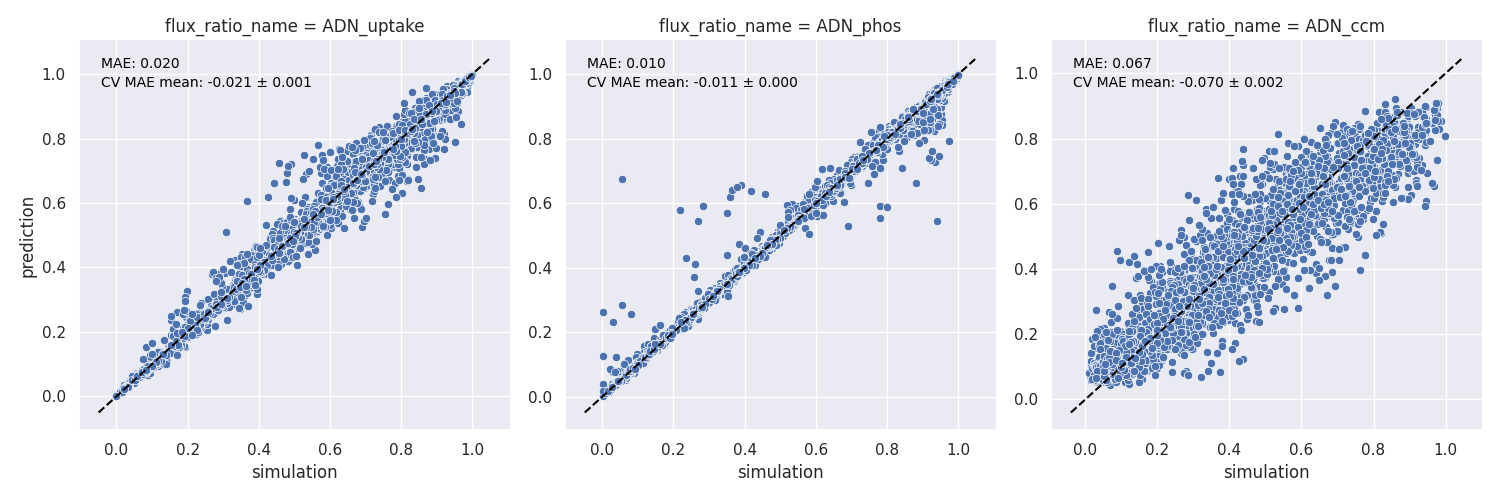

In [30]:
res_glc, df_feat_imp_glc = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_glc, add_flux_ratios_dict)
fg = plot_rf_results(res_glc, col_wrap=3)

In [31]:
df_pred_glc = (
    pd.concat([
        get_rf_pred_results(res_glc, df_exp_glc, "Adenosine"),
        get_rf_pred_results(res_glc, df_exp_glc_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="glc")
)

df_pred_glc

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.825629,0.669018,0.946368,0.020218,-0.021174,0.001061,ADN,uptake,glc
1,Adenosine,ADN_phos,0.942851,0.900919,0.996268,0.010149,-0.011083,0.000260,ADN,phos,glc
2,Adenosine,ADN_ccm,0.554442,0.261259,0.86753,0.067146,-0.070112,0.002079,ADN,ccm,glc
3,Glucose,ADN_uptake,0.171985,0.083546,0.293485,0.020218,-0.021174,0.001061,ADN,uptake,glc
4,Glucose,ADN_phos,0.023611,0.000271,0.069876,0.010149,-0.011083,0.000260,ADN,phos,glc
5,Glucose,ADN_ccm,0.659136,0.241728,0.908423,0.067146,-0.070112,0.002079,ADN,ccm,glc


In [32]:
df_exp_glc.pipe(check_mdv_nan), df_exp_glc_glucose.pipe(check_mdv_nan)

([], [])

## Both features

RF model on all features detected in both the given nucleoside condition and GLC condition

In [33]:
isotopo_list_both = list(set(isotopo_list_wo_nuc).intersection(isotopo_list_glc))
df_exp_both = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_both)
df_exp_both_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_both)
df_mdvs_both = df_mdvs_with_noise.reindex(isotopo_list_both)

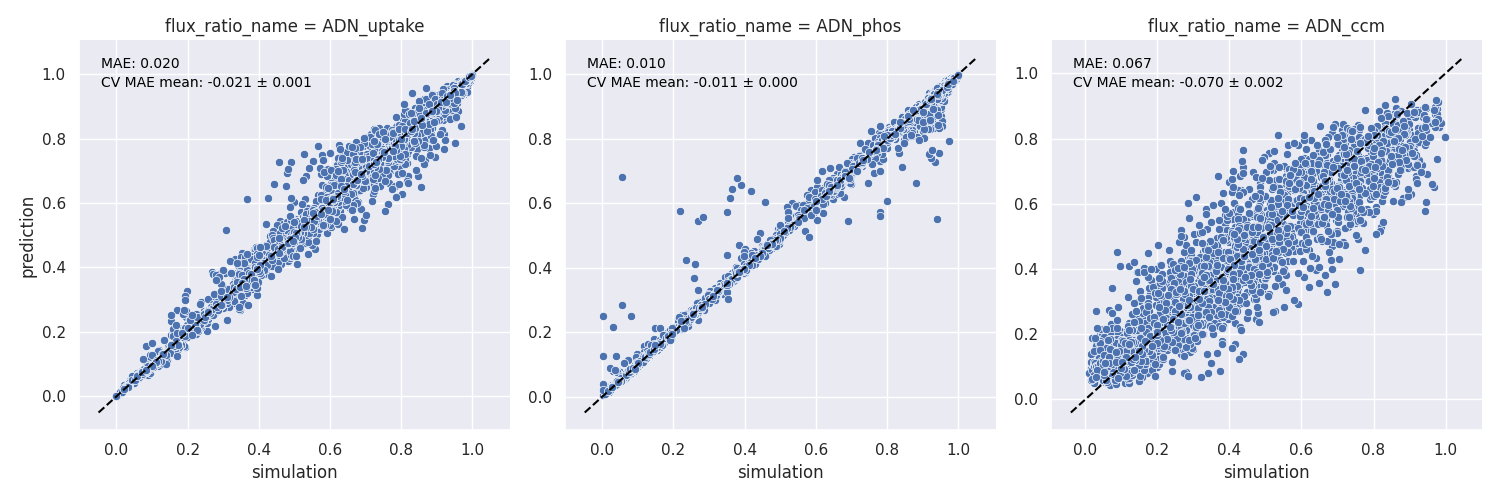

In [34]:
res_both, df_feat_imp_both = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_both, add_flux_ratios_dict)
fg = plot_rf_results(res_both, col_wrap=3)

In [35]:
df_pred_both = (
    pd.concat([
        get_rf_pred_results(res_both, df_exp_both, "Adenosine"),
        get_rf_pred_results(res_both, df_exp_both_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="both")
)

df_pred_both

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.833006,0.686777,0.949526,0.020210,-0.021159,0.001050,ADN,uptake,both
1,Adenosine,ADN_phos,0.942738,0.901352,0.993636,0.010125,-0.011069,0.000260,ADN,phos,both
2,Adenosine,ADN_ccm,0.53557,0.230512,0.843306,0.067202,-0.070077,0.002039,ADN,ccm,both
3,Glucose,ADN_uptake,0.168342,0.081918,0.287568,0.020210,-0.021159,0.001050,ADN,uptake,both
4,Glucose,ADN_phos,0.025387,0.000279,0.069876,0.010125,-0.011069,0.000260,ADN,phos,both
5,Glucose,ADN_ccm,0.649981,0.31334,0.923117,0.067202,-0.070077,0.002039,ADN,ccm,both


In [36]:
df_exp_both.pipe(check_mdv_nan), df_exp_both_glucose.pipe(check_mdv_nan)

([], [])

In [37]:
df_pred_all = pd.concat([
    df_pred_full, df_pred_wo_nuc, df_pred_glc, df_pred_both
], ignore_index=True)
df_pred_all

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.683189,0.115203,0.919737,0.020315,-0.021249,0.000943,ADN,uptake,full
1,Adenosine,ADN_phos,0.939261,0.895835,0.996268,0.010626,-0.011486,0.000280,ADN,phos,full
2,Adenosine,ADN_ccm,0.617268,0.373196,0.82731,0.064999,-0.068399,0.001931,ADN,ccm,full
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020315,-0.021249,0.000943,ADN,uptake,full
4,Glucose,ADN_phos,NaN,NaN,NaN,0.010626,-0.011486,0.000280,ADN,phos,full
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.064999,-0.068399,0.001931,ADN,ccm,full
6,Adenosine,ADN_uptake,0.822276,0.687745,0.949056,0.020221,-0.021145,0.001040,ADN,uptake,wo nuc
7,Adenosine,ADN_phos,0.943786,0.901577,0.993938,0.010097,-0.011095,0.000281,ADN,phos,wo nuc
8,Adenosine,ADN_ccm,0.563209,0.263756,0.881728,0.067101,-0.070170,0.002042,ADN,ccm,wo nuc
9,Glucose,ADN_uptake,NaN,NaN,NaN,0.020221,-0.021145,0.001040,ADN,uptake,wo nuc


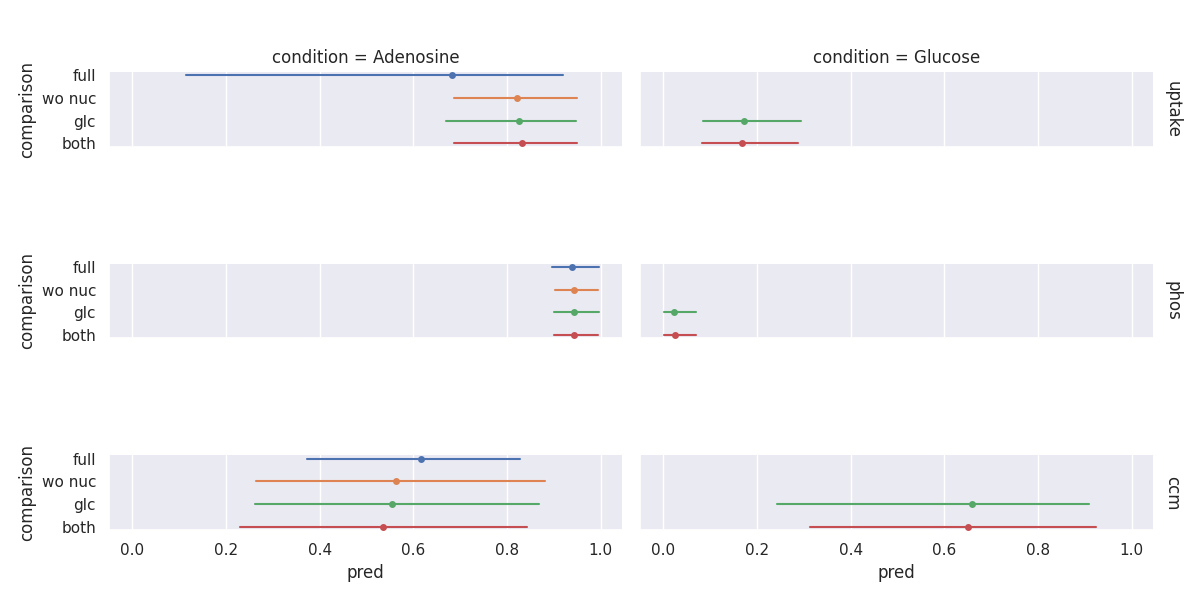

In [38]:
fg = (
    sns.FacetGrid(
        df_pred_all,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [39]:
df_feat_imp_wo_nuc.query("ratio_name == 'ADN_uptake'").head(20)

,feature,importance,ratio_name
0,ADE_12345_0,0.857606,ADN_uptake
7,AMP_12345678910_1,0.062790,ADN_uptake
1,ADE_12345_1,0.030703,ADN_uptake
15,AMP_12345678910_9,0.007296,ADN_uptake
6,AMP_12345678910_0,0.005851,ADN_uptake
14,AMP_12345678910_8,0.004976,ADN_uptake
4,ADE_12345_4,0.004847,ADN_uptake
8,AMP_12345678910_2,0.001484,ADN_uptake
42,G6P_123456_1,0.001100,ADN_uptake
16,AMP_12345678910_10,0.001040,ADN_uptake


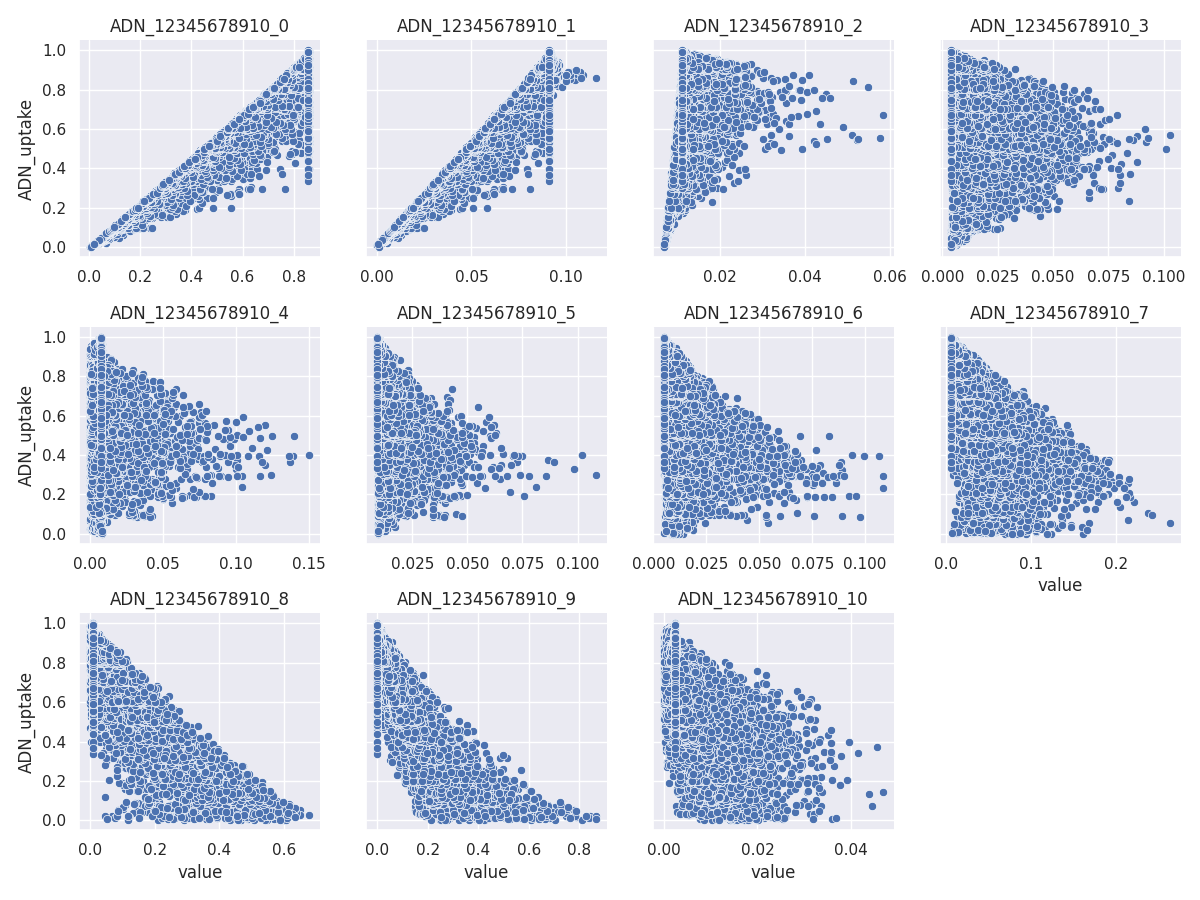

In [40]:
df_tmp = (
    df_mdvs_full
    .reset_index(names="isotopo")
    .query("isotopo.str.startswith('ADN')")
    .set_index("isotopo")
    .transpose()
    .melt(ignore_index=False)
    .join(
        (df_fluxes.loc["ADNin"] / (df_fluxes.loc["RAICAR"] + df_fluxes.loc["ADNin"])).to_frame(name="ADN_uptake")
    )
)

fg = (
    sns.FacetGrid(
        df_tmp,
        col="isotopo",
        col_wrap=4,
        sharex=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="value",
        y="ADN_uptake"
    )
    .set_titles(col_template="{col_name}")
)

# Feature removal

In [41]:
df_mdvs_with_noise_sel = (
    df_mdvs_with_noise[(df_mdvs_with_noise > 0.05).any(axis=1)]
)
df_mdvs_with_noise_sel

,0,1,2,3,4,5,6,7,8,9,...,10990,10991,10992,10993,10994,10995,10996,10997,10998,10999
isotopo,,,,,,,,,,,,,,,,,,,,,
ADE_12345_0,0.649422,0.507333,0.588975,0.549912,0.411224,0.459046,0.512478,0.320390,0.907895,0.556954,...,0.922660,0.922660,0.922660,0.922660,0.922660,0.922660,0.922660,0.922660,0.922660,0.922660
ADE_12345_1,0.035208,0.031179,0.033215,0.029850,0.021257,0.024653,0.027010,0.017478,0.047701,0.031396,...,0.048426,0.048426,0.048426,0.048426,0.048426,0.048426,0.048426,0.048426,0.048426,0.048426
ADE_12345_2,0.033570,0.064399,0.044160,0.060186,0.017926,0.025878,0.020845,0.033502,0.009206,0.045202,...,0.008016,0.008016,0.008016,0.008016,0.008016,0.008016,0.008016,0.008016,0.008016,0.008016
ADE_12345_3,0.032598,0.072492,0.044831,0.049954,0.042626,0.049944,0.042810,0.081530,0.007400,0.048207,...,0.003833,0.003833,0.003833,0.003833,0.003833,0.003833,0.003833,0.003833,0.003833,0.003833
ADE_12345_4,0.213969,0.278795,0.253368,0.274347,0.448708,0.388906,0.348860,0.482907,0.015334,0.276619,...,0.007857,0.007857,0.007857,0.007857,0.007857,0.007857,0.007857,0.007857,0.007857,0.007857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dADN_12345678910_6,0.021264,0.029826,0.019670,0.014979,0.020331,0.023168,0.019611,0.030494,0.006379,0.020090,...,0.007592,0.022842,0.017278,0.013274,0.061805,0.031176,0.037535,0.037847,0.058953,0.045181
dADN_12345678910_7,0.079764,0.089501,0.032776,0.042546,0.078186,0.062530,0.072469,0.123726,0.009866,0.059822,...,0.014895,0.091066,0.057837,0.037899,0.150658,0.071755,0.080224,0.113725,0.195367,0.137124
dADN_12345678910_8,0.267167,0.280527,0.082021,0.190909,0.333628,0.258922,0.277351,0.391955,0.009079,0.200601,...,0.066421,0.296663,0.184584,0.086584,0.334265,0.182871,0.192795,0.300872,0.435677,0.323189


## Full

Full RF model on all features in the given nucleoside condition

In [42]:
isotopo_list_full_sel = get_features_list(df_mdvs_with_noise_sel, df_exp, "Adenosine")
df_exp_full_sel = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_full_sel)
df_exp_full_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_full_sel)
df_mdvs_full_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_full_sel)

In [43]:
res_full_sel, df_feat_imp_full_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_full_sel, add_flux_ratios_dict)

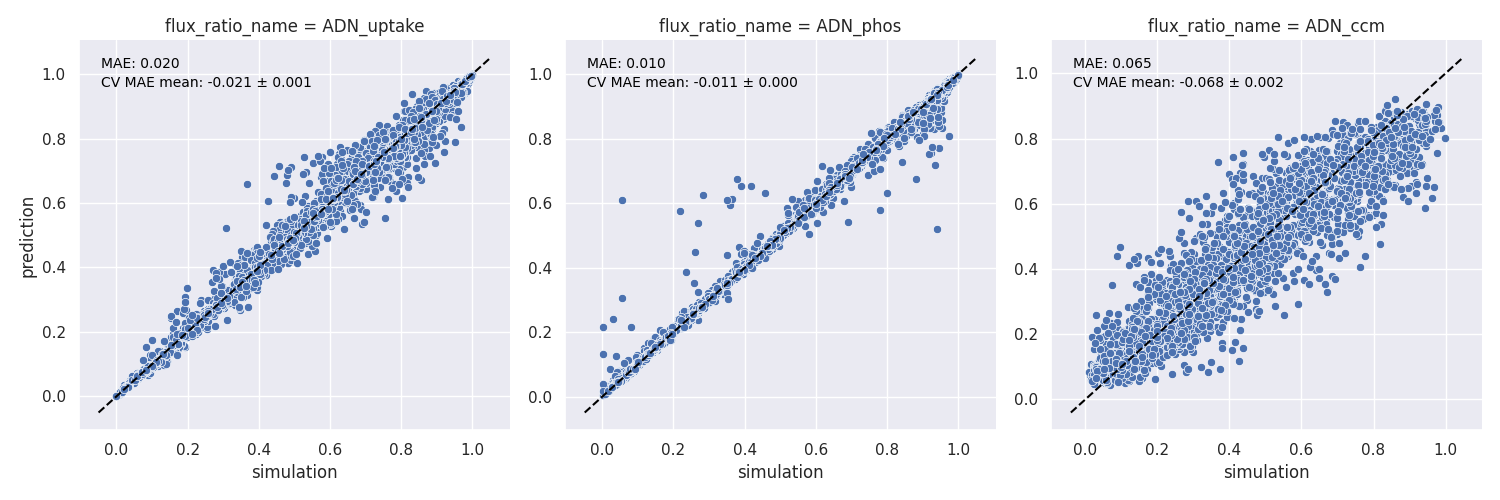

In [44]:
fg = plot_rf_results(res_full_sel, col_wrap=3)

In [45]:
df_pred_full_sel = (
    pd.concat([
        get_rf_pred_results(res_full_sel, df_exp_full_sel, "Adenosine"),
        get_rf_pred_results(res_full_sel, df_exp_full_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="full_sel")
)

df_pred_full_sel

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.677593,0.172072,0.930654,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
1,Adenosine,ADN_phos,0.940369,0.901782,0.993682,0.009807,-0.010816,0.000316,ADN,phos,full_sel
2,Adenosine,ADN_ccm,0.6159,0.351993,0.885577,0.065359,-0.068207,0.001980,ADN,ccm,full_sel
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
4,Glucose,ADN_phos,NaN,NaN,NaN,0.009807,-0.010816,0.000316,ADN,phos,full_sel
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.065359,-0.068207,0.001980,ADN,ccm,full_sel


In [46]:
def check_mdv_nan(data):
    return (
        data
        .query("mdv.isna()")
        .index.str.extract("(.*)_.*_.*")
        .drop_duplicates()
        .iloc[:, 0]
        .tolist()
    )

In [47]:
df_exp_full_sel.pipe(check_mdv_nan), df_exp_full_sel_glucose.pipe(check_mdv_nan)

([], ['ADN', 'Val'])

## Without nucleoside

RF model on all features in the given nucleoside condition without nucleoside itself

In [48]:
isotopo_list_wo_nuc_sel = get_features_list(df_mdvs_with_noise_sel, df_exp.query("~isotopo.str.startswith('ADN')"), "Adenosine")
df_exp_wo_nuc_sel = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_wo_nuc_sel)
df_exp_wo_nuc_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_wo_nuc_sel)
df_mdvs_wo_nuc_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_wo_nuc_sel)

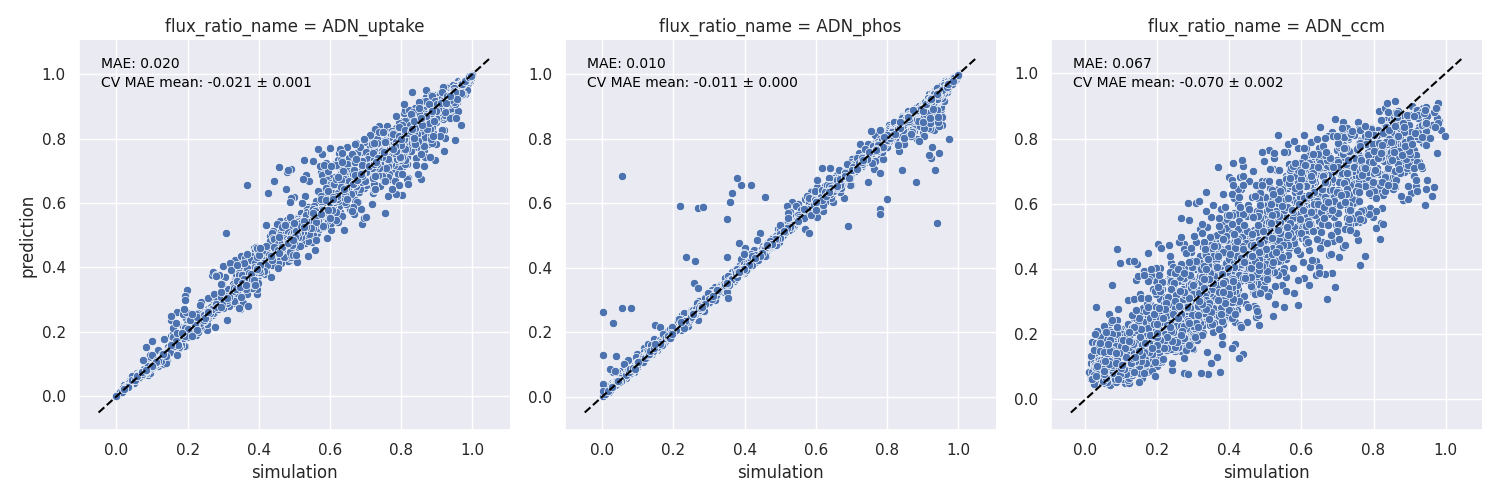

In [49]:
res_wo_nuc_sel, df_feat_imp_wo_nuc_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_wo_nuc_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_wo_nuc_sel, col_wrap=3)

In [50]:
df_pred_wo_nuc_sel = (
    pd.concat([
        get_rf_pred_results(res_wo_nuc_sel, df_exp_wo_nuc_sel, "Adenosine"),
        get_rf_pred_results(res_wo_nuc_sel, df_exp_wo_nuc_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="wo nuc sel")
)

df_pred_full_sel

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.677593,0.172072,0.930654,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
1,Adenosine,ADN_phos,0.940369,0.901782,0.993682,0.009807,-0.010816,0.000316,ADN,phos,full_sel
2,Adenosine,ADN_ccm,0.6159,0.351993,0.885577,0.065359,-0.068207,0.001980,ADN,ccm,full_sel
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
4,Glucose,ADN_phos,NaN,NaN,NaN,0.009807,-0.010816,0.000316,ADN,phos,full_sel
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.065359,-0.068207,0.001980,ADN,ccm,full_sel


In [51]:
df_exp_wo_nuc_sel.pipe(check_mdv_nan), df_exp_wo_nuc_sel_glucose.pipe(check_mdv_nan)

([], ['Val'])

## Glucose features 

RF model on all features in GLC condition

In [52]:
isotopo_list_glc_sel = get_features_list(df_mdvs_with_noise_sel, df_exp, "Glucose")
df_exp_glc_sel = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_glc_sel)
df_exp_glc_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_glc_sel)
df_mdvs_glc_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_glc_sel)

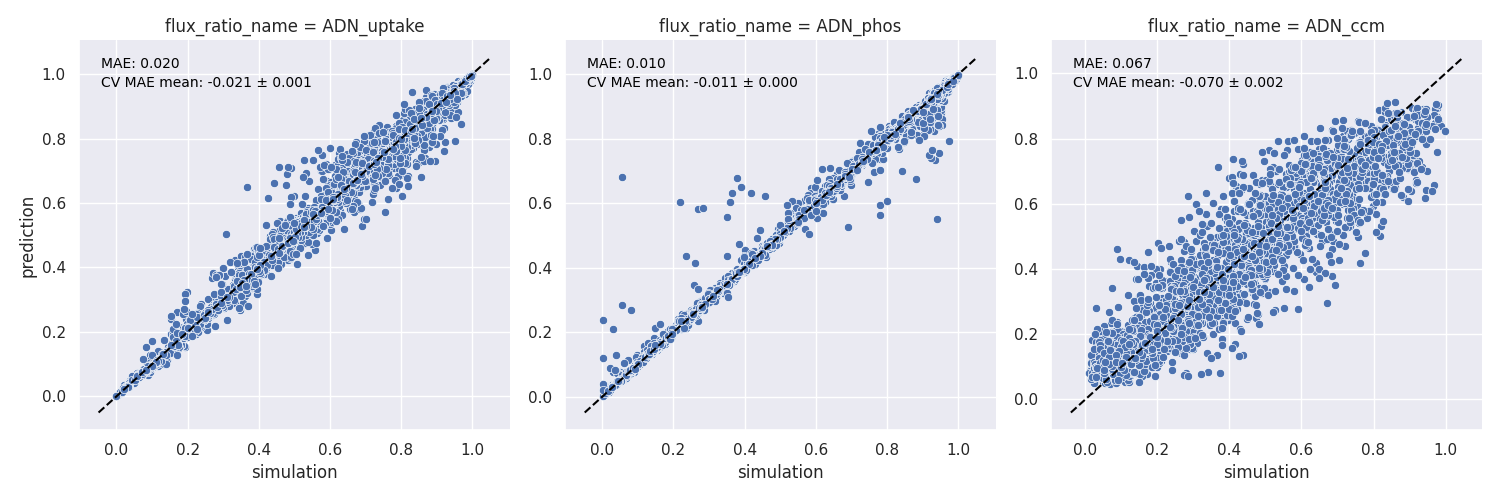

In [53]:
res_glc_sel, df_feat_imp_glc_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_glc_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_glc_sel, col_wrap=3)

In [54]:
df_pred_glc_sel = (
    pd.concat([
        get_rf_pred_results(res_glc_sel, df_exp_glc_sel, "Adenosine"),
        get_rf_pred_results(res_glc_sel, df_exp_glc_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="glc_sel")
)

df_pred_glc_sel

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.833526,0.68762,0.956,0.020198,-0.021307,0.001083,ADN,uptake,glc_sel
1,Adenosine,ADN_phos,0.938972,0.897023,0.994349,0.010094,-0.011021,0.000273,ADN,phos,glc_sel
2,Adenosine,ADN_ccm,0.55984,0.262016,0.881683,0.067439,-0.069939,0.002223,ADN,ccm,glc_sel
3,Glucose,ADN_uptake,0.167602,0.08235,0.279328,0.020198,-0.021307,0.001083,ADN,uptake,glc_sel
4,Glucose,ADN_phos,0.029163,0.000279,0.071531,0.010094,-0.011021,0.000273,ADN,phos,glc_sel
5,Glucose,ADN_ccm,0.650833,0.294272,0.906148,0.067439,-0.069939,0.002223,ADN,ccm,glc_sel


In [55]:
df_exp_glc_sel.pipe(check_mdv_nan), df_exp_glc_sel_glucose.pipe(check_mdv_nan)

([], [])

## Both features

RF model on all features detected in both the given nucleoside condition and GLC condition

In [56]:
isotopo_list_both_sel = list(set(isotopo_list_wo_nuc_sel).intersection(isotopo_list_glc_sel))
df_exp_both_sel = df_exp_w_noise.pipe(get_features_from_exp, "Adenosine", isotopo_list_both_sel)
df_exp_both_sel_glucose = df_exp_w_noise.pipe(get_features_from_exp, "Glucose", isotopo_list_both_sel)
df_mdvs_both_sel = df_mdvs_with_noise_sel.reindex(isotopo_list_both_sel)

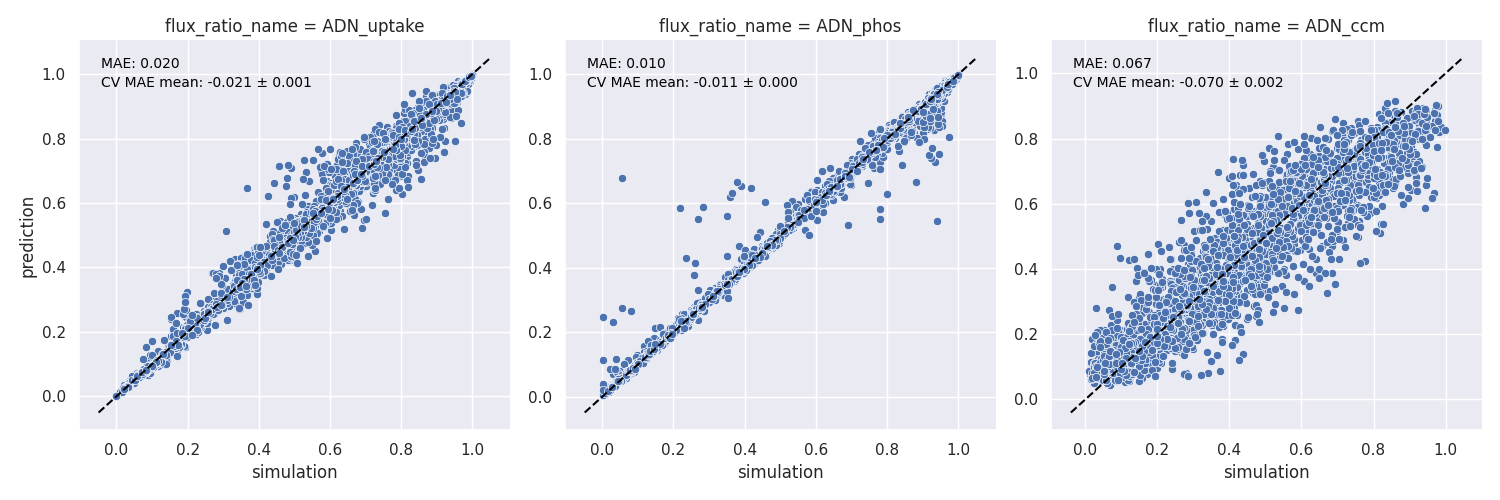

In [57]:
res_both_sel, df_feat_imp_both_sel = train_rf_for_all_flux_ratios(df_fluxes, df_mdvs_both_sel, add_flux_ratios_dict)
fg = plot_rf_results(res_both_sel, col_wrap=3)

In [58]:
df_pred_both_sel = (
    pd.concat([
        get_rf_pred_results(res_both_sel, df_exp_both_sel, "Adenosine"),
        get_rf_pred_results(res_both_sel, df_exp_both_sel_glucose, "Glucose")
    ], ignore_index=True)
    .assign(comparison="both_sel")
)

df_pred_both_sel

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.836543,0.735031,0.946637,0.020217,-0.021279,0.001066,ADN,uptake,both_sel
1,Adenosine,ADN_phos,0.941843,0.89784,0.993938,0.010088,-0.011001,0.000252,ADN,phos,both_sel
2,Adenosine,ADN_ccm,0.54541,0.260437,0.880023,0.067351,-0.069936,0.002197,ADN,ccm,both_sel
3,Glucose,ADN_uptake,0.171798,0.073619,0.286913,0.020217,-0.021279,0.001066,ADN,uptake,both_sel
4,Glucose,ADN_phos,0.032638,0.000279,0.086609,0.010088,-0.011001,0.000252,ADN,phos,both_sel
5,Glucose,ADN_ccm,0.660129,0.399592,0.890923,0.067351,-0.069936,0.002197,ADN,ccm,both_sel


In [59]:
df_exp_both_sel.pipe(check_mdv_nan), df_exp_both_sel_glucose.pipe(check_mdv_nan)

([], [])

In [60]:
df_pred_all_sel = pd.concat([
    df_pred_full_sel, df_pred_wo_nuc_sel, df_pred_glc_sel, df_pred_both_sel
], ignore_index=True)
df_pred_all_sel

,condition,flux_ratio,pred,pred_q10,pred_q90,mae,cv_mae_mean,cv_mae_sd,nucleoside,flux_ratio_name,comparison
0,Adenosine,ADN_uptake,0.677593,0.172072,0.930654,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
1,Adenosine,ADN_phos,0.940369,0.901782,0.993682,0.009807,-0.010816,0.000316,ADN,phos,full_sel
2,Adenosine,ADN_ccm,0.6159,0.351993,0.885577,0.065359,-0.068207,0.001980,ADN,ccm,full_sel
3,Glucose,ADN_uptake,NaN,NaN,NaN,0.020335,-0.021304,0.001005,ADN,uptake,full_sel
4,Glucose,ADN_phos,NaN,NaN,NaN,0.009807,-0.010816,0.000316,ADN,phos,full_sel
5,Glucose,ADN_ccm,NaN,NaN,NaN,0.065359,-0.068207,0.001980,ADN,ccm,full_sel
6,Adenosine,ADN_uptake,0.826631,0.706003,0.949056,0.020210,-0.021253,0.001117,ADN,uptake,wo nuc sel
7,Adenosine,ADN_phos,0.937743,0.897023,0.993654,0.010101,-0.011026,0.000255,ADN,phos,wo nuc sel
8,Adenosine,ADN_ccm,0.557484,0.253371,0.904379,0.067387,-0.069930,0.002193,ADN,ccm,wo nuc sel
9,Glucose,ADN_uptake,NaN,NaN,NaN,0.020210,-0.021253,0.001117,ADN,uptake,wo nuc sel


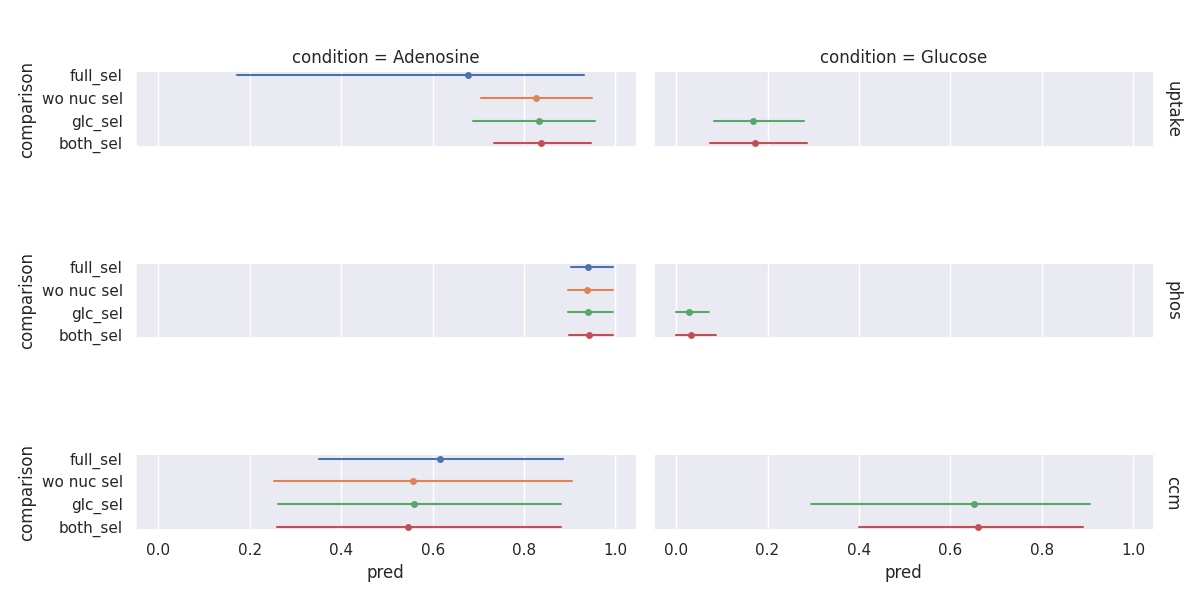

In [61]:
fg = (
    sns.FacetGrid(
        df_pred_all_sel,
        row="flux_ratio_name",
        col="condition",
        aspect=3,
        height=2,
        margin_titles=True
    )
    .map_dataframe(lineplots, y="comparison")
    .set_titles(row_template="{row_name}")
)
fg

In [62]:
df_feat_imp_full_sel.query("ratio_name == 'ADN_uptake'").head(20)

,feature,importance,ratio_name
6,ADN_12345678910_0,0.358787,ADN_uptake
0,ADE_12345_0,0.307238,ADN_uptake
7,ADN_12345678910_1,0.203955,ADN_uptake
17,AMP_12345678910_1,0.058085,ADN_uptake
1,ADE_12345_1,0.023919,ADN_uptake
25,AMP_12345678910_9,0.007263,ADN_uptake
16,AMP_12345678910_0,0.006098,ADN_uptake
24,AMP_12345678910_8,0.005144,ADN_uptake
15,ADN_12345678910_9,0.002751,ADN_uptake
18,AMP_12345678910_2,0.001384,ADN_uptake


In [63]:
df_pred = pd.concat([
    df_pred_all.assign(feature_subset=False), 
    df_pred_all_sel.assign(feature_subset=True)
], ignore_index=True)

df_pred.to_csv("../Output/CofeedBuni/adn_predictions.csv", index=False)

## Additional plots

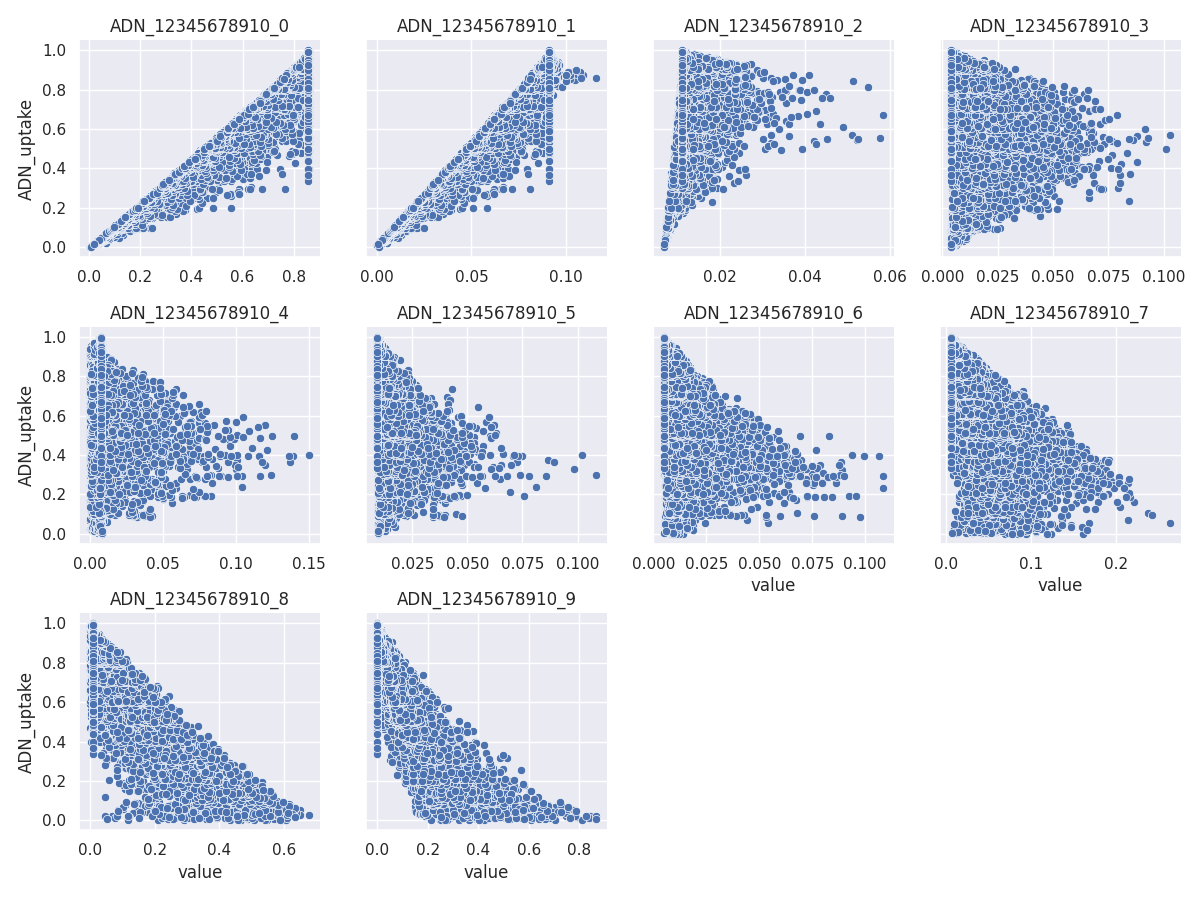

In [64]:
df_tmp = (
    df_mdvs_full_sel
    .transpose()
    .melt(ignore_index=False)
    .join(
        (df_fluxes.loc["ADNin"] / (df_fluxes.loc["RAICAR"] + df_fluxes.loc["ADNin"])).to_frame(name="ADN_uptake")
    )
)

fg = (
    sns.FacetGrid(
        df_tmp.query("isotopo.str.startswith('ADN')"),
        col="isotopo",
        col_wrap=4,
        sharex=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="value",
        y="ADN_uptake"
    )
    .set_titles(col_template="{col_name}")
)

In [65]:
df_mdv_comp = (
    pd.merge(
        df_mdvs
            .melt(ignore_index=False, var_name="sim_num", value_name="mdv_wo_noise")
            .reset_index(names="isotopo"),
        df_mdvs_with_noise
            .melt(ignore_index=False, var_name="sim_num", value_name="mdv_w_noise")
            .reset_index(names="isotopo"),
        on=["isotopo", "sim_num"],
        how="inner"
    )
    .assign(mb=lambda x: x.isotopo.str.extract("(.*)_.*_.*"))
)


<Axes: xlabel='mdv_wo_noise', ylabel='mdv_w_noise'>

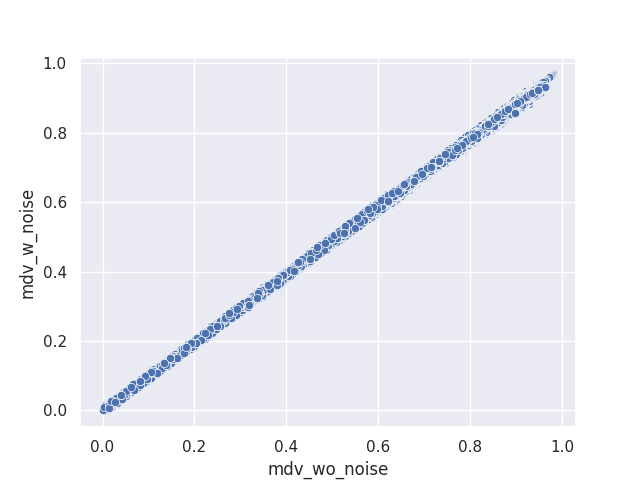

In [66]:
fig, ax = plt.subplots()
sns.scatterplot(df_mdv_comp, x="mdv_wo_noise", y="mdv_w_noise")

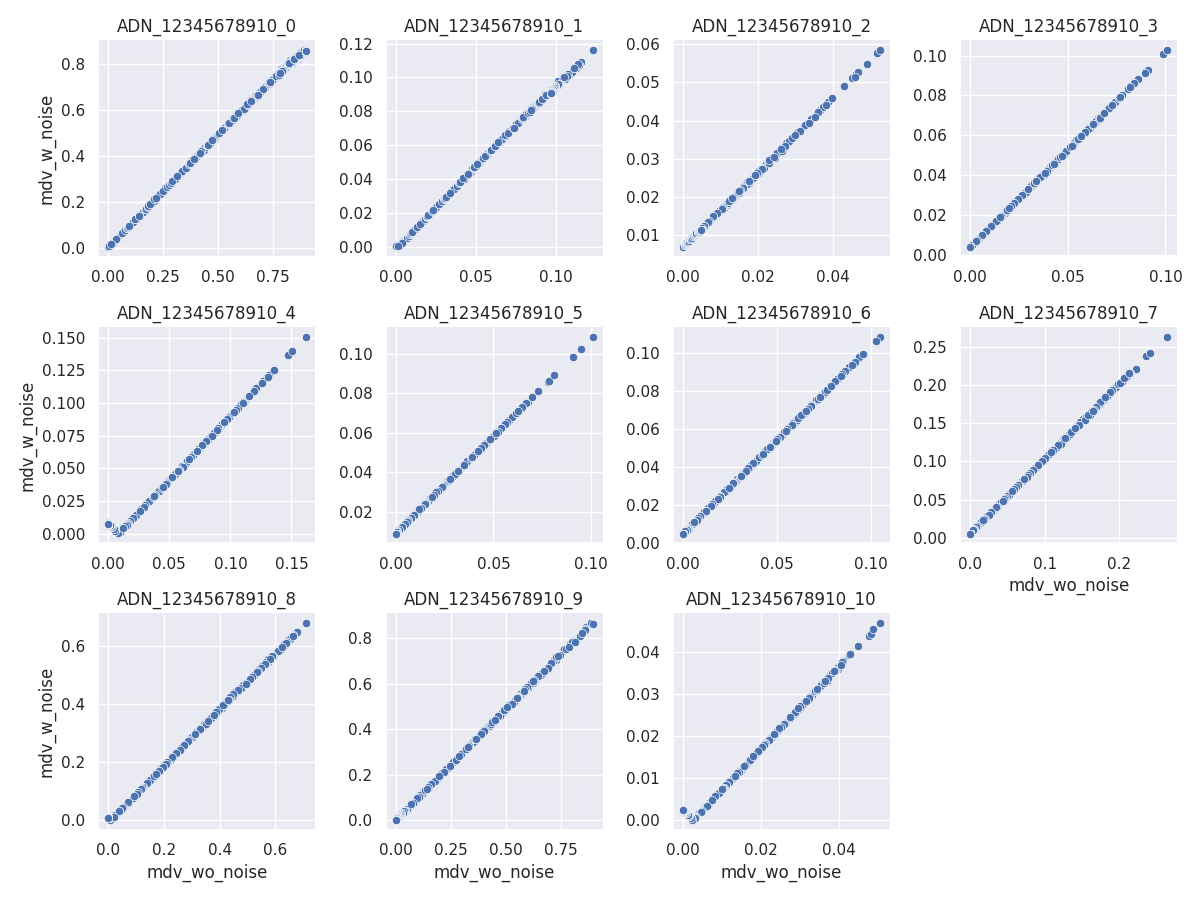

In [67]:
fg = (
    sns.FacetGrid(
        df_mdv_comp.query("mb == 'ADN'"),
        col="isotopo",
        col_wrap=4,
        sharex=False,
        sharey=False
    )
    .map_dataframe(
        sns.scatterplot,
        x="mdv_wo_noise",
        y="mdv_w_noise"
    )
    .set_titles(col_template="{col_name}")
)

## SHAP

In [68]:
import shap

In [69]:
shap_train, shap_test = train_test_split(
    df_mdvs_full_sel.transpose(),
    test_size=0.3,
    random_state=42,
)

In [70]:
explainer = shap.TreeExplainer(res_full_sel['ADN_uptake'][0])
rf_prob_shap_vals = explainer(shap_test)

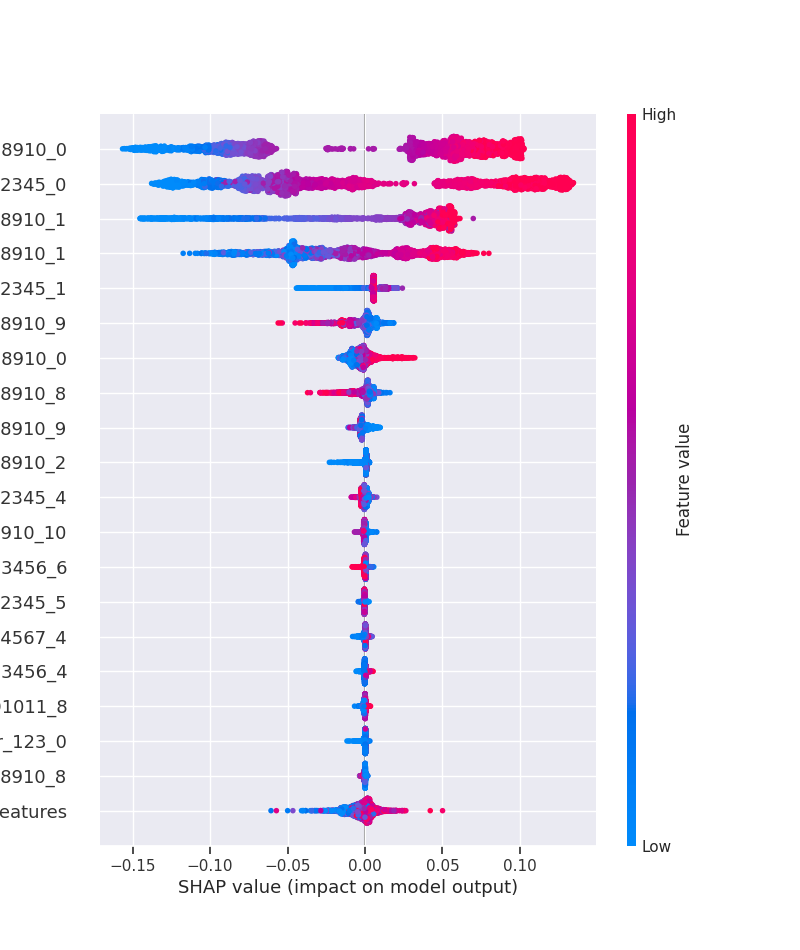

In [71]:
fig, ax = plt.subplots()
shap.plots.beeswarm(rf_prob_shap_vals[:], max_display=20)
fig.subplots_adjust(left=0.4)